# Thursday March 5th
## Announcements
- Assignment 3 due Wednesday March 11th at 11:59pm
- Midterm 2 March 12th, 7:00pm-9:00pm in KTH B135
    - Topics for midterm 2 include up until the end of todays lecture.

# Chapter 9: more numpy
A few more topics in somewhat random order

## 9.8 Reading and writing files
Reading data from *text* files is relatively straightforward. We'll see later how to handle some other types of files.


In [15]:
f = open('text.txt', 'w')
f.write('test')

4

In [16]:
import numpy as np
A2 = np.array([[1, 2, 3], [4, 5, 6]])
np.savetxt('testfile.txt', A2)
np.savetxt('testfile.csv', A2, delimiter=',', header='col1, col2, col3')

# use the help for more options and their meaning 
# help(np.savetxt) 

Conversely, we can import data from text files: 

In [19]:
grades = np.loadtxt('grades.csv', skiprows = (1), usecols = (9), delimiter = ',')
print(grades)

[ 91.  88.  87.  84.  81.  95.  92.  89.  91.  90.  86.  85.  91.  89.
  85.  87.  82.  77.  85.  90.  92.  95.  85.  90.  97.  85.  85.  89.
  89.  87.  86.  85.  76.  89.  91.  82.  85.  85.  89.  94.  92.  82.
  88.  92.  82.  88.  84.  86.  77.  81.  82.  81.  85.  85.  80.  82.
  87.  93.  80.  75.  92.  75.  83.  88.  92.  87.  86.  93.  84.  81.
  89.  92.  89.  88.  95.  85.  91.  91.  84.  85.  83.  82.  83.  82.
  88.  85.  93.  91.  90.  76.  88. 100.  89.  79.  86.  76.  87.  91.
  86.  78.  83.  76.  92.  87.  90.  82.  85.  85.  79.  90.  88.  80.
  86.  84.  87.  88.  82.  82.  93.  83.  90.  88.  88.  77.  89.  89.
  90.  86.  91.  99.  82.  82.  84.  90.  84.  83.  78.  77.  84.  83.
  79.  91.  87.  84.  92.  85.  82.  84.  87.  85.  89.  90.  85.  87.
  93.  84.  85.  85.  84.  95.  85.  84.  83.  80.  78.  90.  93.  82.
  80.  90.  88.  94.  87.  81.  81.  89.  92.  84.  84.  90.  88.  90.
  86.  84.  89.  89.  94.  83.  94.  92.  92.  87.  83.  88.  90.  88.
  80. 

In [ ]:
type(grades)
print(grades.shape)
print(np.mean(grades))


(251,)
86.35856573705179


## 9.9 Random numbers
`np.random` gives access to several types of random number generators. 

Some of the most relevant are
* `np.random.uniform`: uniformly distributed numbers
* `np.random.normal`: a 'normal' distribute ("bell curve")

**Important note:** Everything Python does is **deterministic**. As such, there is no way for Python to generate a truly random collection of numbers. Every collection of *random* numbers generated by Python is actually **pseudo-random**. However, as it turns out, true randomness is seldom needed.

In [30]:
unif = np.random.uniform(low = -10, high = 10, size = (3,4))
print(unif)


mean = 0
stddev = 5
normal = np.random.normal(0, 5, size=(3,4))
print(normal)

[[ 6.59421181 -6.60289416  3.08005031 -5.73541437]
 [-8.38523902 -9.56451563  8.32321202 -8.93354628]
 [ 8.55310903  7.65117795 -9.98725067  1.06410246]]
[[ 9.20099781 -4.21122975  3.58110442 -0.12353673]
 [ 1.50380818  1.89478711  6.96179004 -4.59529854]
 [-0.81489256 -7.41421876 -6.70122111 -9.1139305 ]]


visualizing the difference:

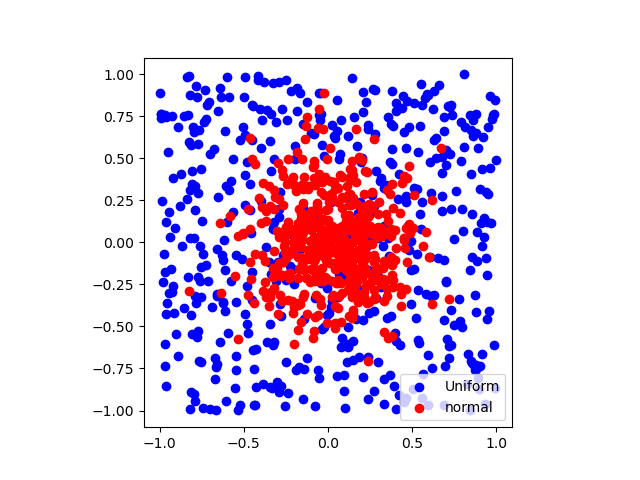

In [31]:
%matplotlib widget
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
n = 501
X = np.random.uniform(low= -1, high = 1, size =(n,))
Y = np.random.uniform(low= -1, high = 1, size =(n,))
ax.scatter(X,Y, color='b', label = 'Uniform')
X = np.random.normal(loc= 0, scale = 0.25, size =(n,))
Y = np.random.normal(loc= 0, scale = 0.25, size =(n,))
ax.scatter(X,Y, color='r', label = 'normal')
ax.set_aspect('equal', 'box')
ax.legend()

## 9.10 Application: A very inefficient away to compute $\pi$.
The idea of the Monte Carlo method to compute $\pi$ is to estimate the probability that a point with uniform random coordinates in (-1,1) is in the circle of diameter 1 is proportional to the ratio of the area of the circle over the square, $\pi/4$

In [32]:
npoints = 100000
ntries = 10
for j in range(ntries):
    XY = np.random.uniform(low = -2, high = 2, size = (npoints, 2))
    insidePoints = [xy for xy in XY if xy[0]**2 + xy[1]**2 <= 1 ]
    outsidePoints = [xy for xy in XY if xy[0]**2 + xy[1]**2 > 1 ]
    piApprox = 16 * len(insidePoints) / npoints
    print(f"After {npoints} trials, pi ~ {piApprox} (error {100*abs((np.pi-piApprox)/np.pi):.2f}%)")


After 100000 trials, pi ~ 3.11248 (error 0.93%)
After 100000 trials, pi ~ 3.14864 (error 0.22%)
After 100000 trials, pi ~ 3.13552 (error 0.19%)
After 100000 trials, pi ~ 3.12688 (error 0.47%)
After 100000 trials, pi ~ 3.13696 (error 0.15%)
After 100000 trials, pi ~ 3.13472 (error 0.22%)
After 100000 trials, pi ~ 3.1816 (error 1.27%)
After 100000 trials, pi ~ 3.1656 (error 0.76%)
After 100000 trials, pi ~ 3.12992 (error 0.37%)
After 100000 trials, pi ~ 3.14352 (error 0.06%)


After 10000 trials, pi ~ 3.1456 (error 0.13%)


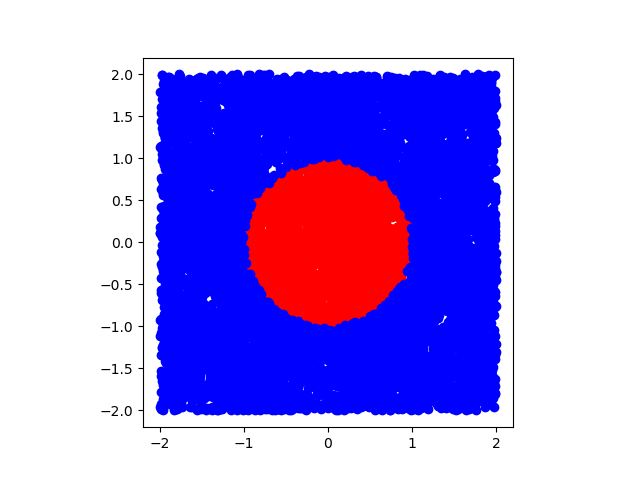

In [33]:
# Same thing with a plot
npoints = 10000
fig, ax = plt.subplots()
XY = np.random.uniform(low = -2, high = 2, size = (npoints, 2))
insidePoints = np.array([xy for xy in XY if xy[0]**2 + xy[1]**2 <= 1 ])
outsidePoints = np.array([xy for xy in XY if xy[0]**2 + xy[1]**2 > 1 ])
piApprox = 16 * len(insidePoints) / npoints
print(f"After {npoints} trials, pi ~ {piApprox} (error {100*abs((np.pi-piApprox)/np.pi):.2f}%)")

ax.scatter(insidePoints[:,0], insidePoints[:,1], color = 'r')
ax.scatter(outsidePoints[:,0], outsidePoints[:,1], color = 'b')
# ax.axis([-1.1, 1.1, -1.1, 1.1])
ax.set_aspect('equal', 'box')


### Application 2 - Approximating $e$

**Fun fact** Consider the following procedure: 
- Choose a real number out of $[0,1]$ at random.
- Check if it is smaller than $1$.
    - If yes...
        - Pick another real number out of $[0,1]$ at random and add it to the first.
        - Check if the result is smaller than $1$, repeat...
    - If no, stop.

This process on average will take $e$ steps to terminate. So, that means we can use randomness to calculate an approximation of $e$.

In [36]:
print(np.e)

2.718281828459045


In [37]:
nums = np.array([])
for i in range(1000):  
    initial = np.random.uniform(low=0,high=1,size=(1,))
    while np.sum(initial)< 1:
        initial = np.hstack((initial,np.random.uniform(low=0,high=1,size=(1,))))
    nums = np.append(nums,len(initial))
print(np.mean(nums))

2.718


## 9.11 The `polynomial` class
In assignment 3, you are implementing polynomial operations. `numpy` contains all of these operations (but you are of course not allowed to use them in the assignment...)

`np.polynomial` introduces a new python type representing a polynomial from its coefficients: `np.polynomial.Polynomial` and a long list of *methods*:
* evaluation: `P(1)`
* algebraic operations: `+`, `-`, `*`
* derivative: `P.deriv()`
* antiderivative: `P.integ()`
* roots: `P.roots()`
* construction from roots: `P.fromroots()`
* see a longer list using python help


In [38]:
P = np.polynomial.Polynomial([1, 2, 3])
print(P)

print(P(0))
print(P*P)
print(P.deriv())

1.0 + 2.0·x + 3.0·x²
1.0
1.0 + 4.0·x + 10.0·x² + 12.0·x³ + 9.0·x⁴
2.0 + 6.0·x


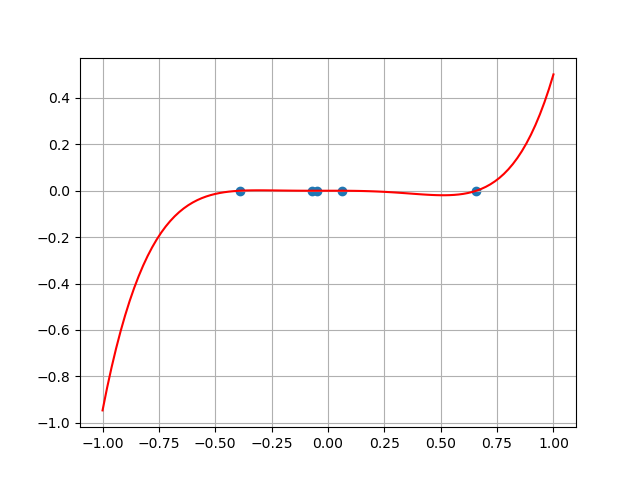

In [40]:
n = 5
X = np.random.uniform(low = -1, high = 1, size = n)
P = np.polynomial.Polynomial.fromroots(X)

fig, ax = plt.subplots()
ax.scatter(X, np.zeros(n))
xplot = np.linspace(-1, 1,101)
ax.plot(xplot, P(xplot), color = 'red')
ax.grid()


-0.33636882 + 0.75174459·x + 0.84156586·x²


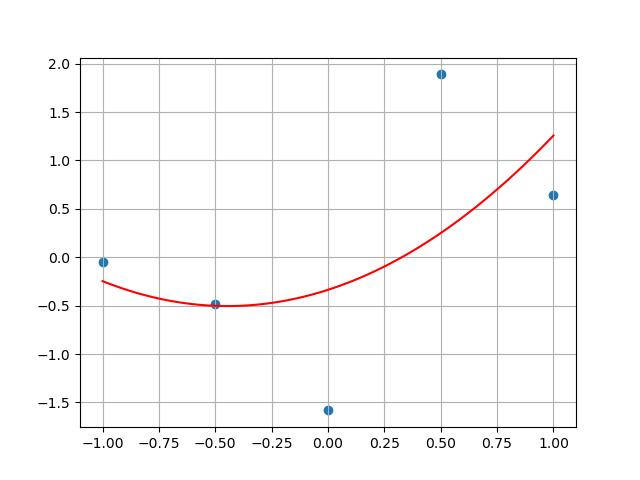

In [43]:
n = 5
X = np.linspace(-1, 1, n)
Y = np.random.uniform(low = -2, high = 2, size = n)
P = np.polynomial.Polynomial.fit(X,Y,2)
print(P)

fig, ax = plt.subplots()
ax.scatter(X, Y)
xplot = np.linspace(-1, 1,101)
ax.plot(xplot, P(xplot), color = 'red')
ax.grid()


In [ ]:
X = 